# GEO-Bench Experiment Results Visualizer

Scans all experiment directories under a root folder, loads `metrics.csv` logs,
and renders training curves and final-metric comparisons across runs.

In [1]:
import glob
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from omegaconf import OmegaConf

## Configuration

Set `EXPERIMENTS_ROOT` to the directory that contains your experiment group folders.

In [2]:
# ── adjust this path if you move the notebook ──────────────────────────────────
EXPERIMENTS_ROOT = Path("../../experiments")
# ───────────────────────────────────────────────────────────────────────────────

assert EXPERIMENTS_ROOT.exists(), f"Path does not exist: {EXPERIMENTS_ROOT.resolve()}"

## Discover runs and load metrics

In [3]:
def load_runs(experiments_root: Path) -> pd.DataFrame:
    """Walk the experiments tree and collect metrics from every csv_logs version.

    Returns a tidy DataFrame with one row per (step, metric) observation.
    """
    records = []

    # Pattern: <root>/<group>/<run_name>/<dataset>/<seed>/csv_logs/<version>/metrics.csv
    pattern = str(experiments_root / "**" / "csv_logs" / "*" / "metrics.csv")
    csv_files = sorted(glob.glob(pattern, recursive=True))

    for csv_path in csv_files:
        p = Path(csv_path)
        # Derive human-readable labels from directory structure
        version = p.parent.name          # e.g. version_0
        seed_dir = p.parents[3]          # e.g. seed_0
        dataset_dir = seed_dir.parent    # e.g. m-forestnet
        run_dir = dataset_dir.parent     # e.g. 1.00x_train_..._tl
        group_dir = run_dir.parent       # e.g. prithvi_forestnet

        # Try to get model variant from config.yaml next to metrics.csv
        config_path = p.parent / "config.yaml"
        model_variant = "unknown"
        partition = "unknown"
        if config_path.exists():
            try:
                cfg = OmegaConf.load(str(config_path))
                model_variant = cfg.get("model", {}).get("prithvi_variant", None) or \
                                cfg.get("model", {}).get("backbone", None) or "unknown"
                partition = cfg.get("experiment", {}).get("partition_name", "unknown")
            except Exception:
                pass

        # Also try the job-level config.yaml (parent of csv_logs)
        job_config = seed_dir / "config.yaml"
        if job_config.exists() and (model_variant == "unknown" or partition == "unknown"):
            try:
                cfg = OmegaConf.load(str(job_config))
                if model_variant == "unknown":
                    model_variant = cfg.get("model", {}).get("prithvi_variant", None) or \
                                    cfg.get("model", {}).get("backbone", None) or "unknown"
                if partition == "unknown":
                    partition = cfg.get("experiment", {}).get("partition_name", "unknown")
            except Exception:
                pass

        run_label = f"{group_dir.name} | {dataset_dir.name} | {seed_dir.name} | {version}"

        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"  [SKIP] Could not read {csv_path}: {e}")
            continue

        if df.empty:
            continue

        df["run_label"] = run_label
        df["group"] = group_dir.name
        df["run_name"] = run_dir.name
        df["dataset"] = dataset_dir.name
        df["seed"] = seed_dir.name
        df["version"] = version
        df["model_variant"] = model_variant
        df["partition"] = partition
        df["csv_path"] = str(csv_path)
        records.append(df)

    if not records:
        raise RuntimeError(f"No metrics.csv files found under {experiments_root.resolve()}")

    all_data = pd.concat(records, ignore_index=True)
    # Normalise epoch column
    all_data["epoch"] = pd.to_numeric(all_data["epoch"], errors="coerce")
    all_data["step"] = pd.to_numeric(all_data["step"], errors="coerce")
    return all_data


all_data = load_runs(EXPERIMENTS_ROOT)
print(f"Loaded {len(all_data):,} rows from {all_data['csv_path'].nunique()} CSV files.")
print("\nRuns found:")
for lbl in sorted(all_data["run_label"].unique()):
    print(" ", lbl)

Loaded 4,828 rows from 7 CSV files.

Runs found:
  experiments | 0.01x_train_prithvi_v2_dummy_classification_v1.0_02-23-2026_15:23:47prithvi_eo_v2_100_tl | m-eurosat | version_0
  experiments | 1.00x_train_prithvi_v2_classification_v1.0_02-23-2026_15:31:18prithvi_eo_v2_100_tl | m-eurosat | version_0
  experiments | 1.00x_train_prithvi_v2_classification_v1.0_02-23-2026_15:31:18prithvi_eo_v2_100_tl | m-eurosat | version_1
  experiments | 1.00x_train_prithvi_v2_forestnet_classification_v1.0_02-23-2026_17:44:58prithvi_eo_v2_100_tl | m-forestnet | version_0
  experiments | 1.00x_train_prithvi_v2_forestnet_classification_v1.0_02-23-2026_17:44:58prithvi_eo_v2_100_tl | m-forestnet | version_1
  experiments | 1.00x_train_prithvi_v2_forestnet_classification_v1.0_03-02-2026_17:25:34prithvi_eo_v2_100_tl | m-forestnet | version_0
  experiments | 1.00x_train_prithvi_v2_pv4ger_classification_v1.0_02-24-2026_17:33:09prithvi_eo_v2_100_tl | m-pv4ger | version_0


## Per-epoch summary

Lightning logs training loss at every N steps and val/test metrics once per epoch.
We build a per-epoch summary by grouping on epoch and taking the last non-null value
for each metric (matching the behaviour of `Job.get_metrics()`).

In [4]:
METRIC_COLS = [
    "train_loss",
    "train_Accuracy",
    "val_Accuracy",
    "val_loss/dataloader_idx_0",
    "val_F1Score",
    "val_Jaccard",
    "test_Accuracy",
    "test_loss",
    "test_loss/dataloader_idx_1",
    "test_F1Score",
    "test_Jaccard",
]

# Keep only columns that actually appear in at least one file
available_metric_cols = [c for c in METRIC_COLS if c in all_data.columns]

group_keys = ["run_label", "group", "dataset", "seed", "version", "model_variant", "partition", "epoch"]
epoch_df = (
    all_data[group_keys + available_metric_cols]
    .groupby(group_keys, dropna=False)
    .last()
    .reset_index()
)

for col in available_metric_cols:
    epoch_df[col] = pd.to_numeric(epoch_df[col], errors="coerce")

print(f"Per-epoch summary: {len(epoch_df)} rows")
epoch_df[["run_label", "epoch"] + available_metric_cols].head(10)

Per-epoch summary: 158 rows


,run_label,epoch,train_loss,train_Accuracy,val_Accuracy,val_loss/dataloader_idx_0,test_Accuracy,test_loss,test_loss/dataloader_idx_1
0,experiments | 0.01x_train_prithvi_v2_dummy_cla...,0,2.651737,0.1000,0.106,2.307974,0.106,NaN,2.306681
1,experiments | 0.01x_train_prithvi_v2_dummy_cla...,1,2.012442,0.2000,0.185,2.206595,0.186,NaN,2.195370
2,experiments | 0.01x_train_prithvi_v2_dummy_cla...,2,1.444326,0.5000,0.270,2.037893,0.275,NaN,2.017660
3,experiments | 0.01x_train_prithvi_v2_dummy_cla...,3,0.908285,0.7500,0.454,1.936420,0.465,NaN,1.906369
4,experiments | 0.01x_train_prithvi_v2_dummy_cla...,4,0.469780,1.0000,0.483,1.975307,0.495,NaN,1.941286
5,experiments | 0.01x_train_prithvi_v2_dummy_cla...,5,NaN,NaN,NaN,NaN,0.495,1.941286,NaN
6,experiments | 1.00x_train_prithvi_v2_classific...,0,0.147272,0.6975,0.820,0.505162,0.816,NaN,0.510679
7,experiments | 1.00x_train_prithvi_v2_classific...,1,0.343429,0.8670,0.864,0.387112,0.874,NaN,0.373501
8,experiments | 1.00x_train_prithvi_v2_classific...,2,0.096372,0.9155,0.907,0.269998,0.885,NaN,0.307373
9,experiments | 1.00x_train_prithvi_v2_classific...,3,0.181206,0.9170,0.888,0.302923,0.907,NaN,0.296779


## Training curves — loss & accuracy

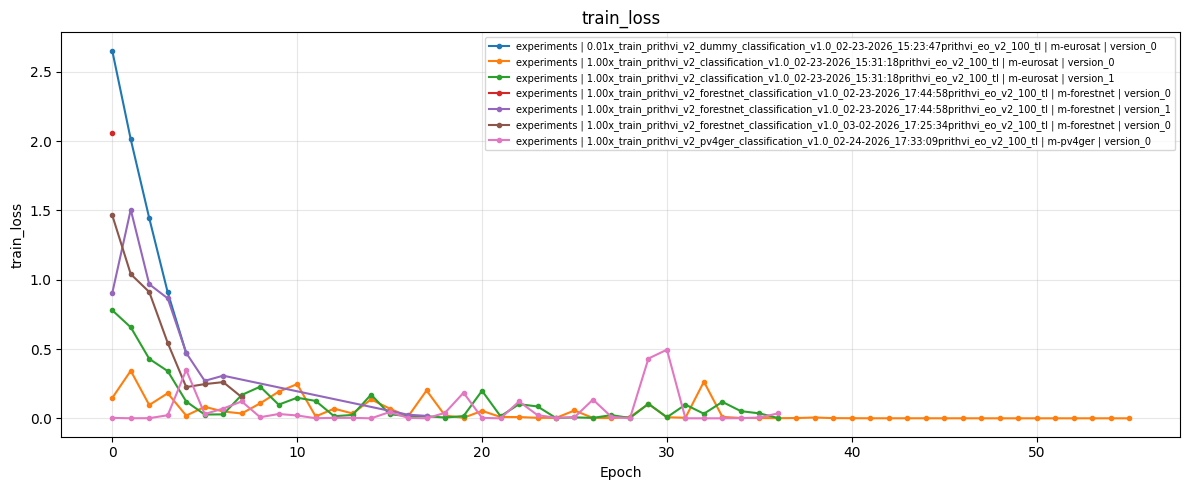

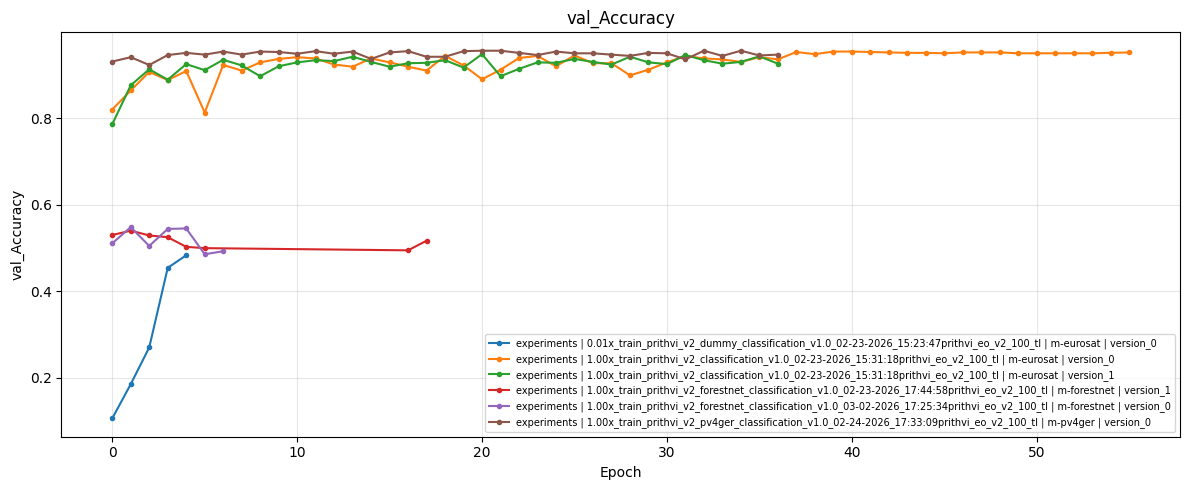

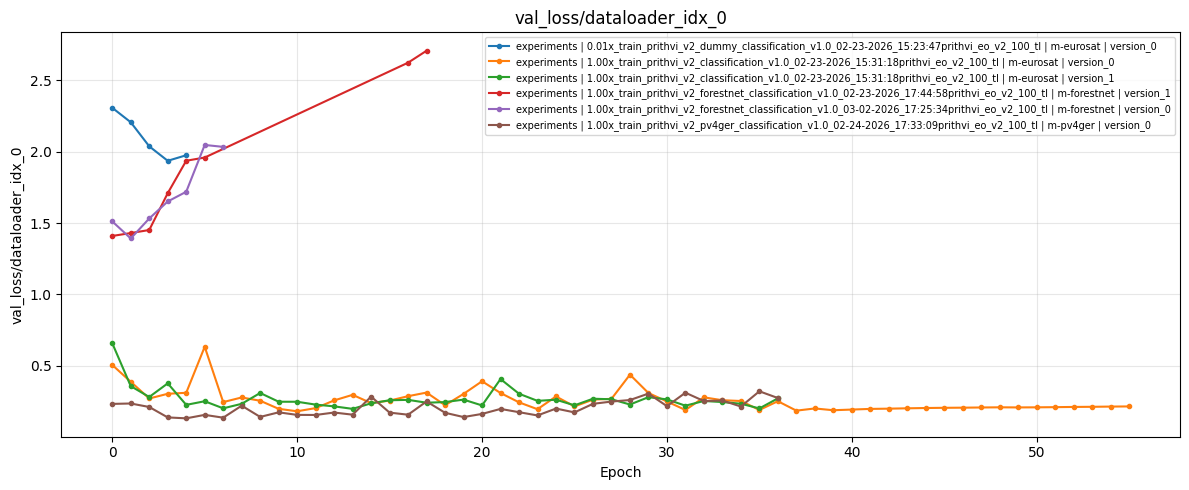

Metric 'val_F1Score' not in data — skipping.
Metric 'val_Jaccard' not in data — skipping.


In [5]:
def plot_curves(epoch_df: pd.DataFrame, metric: str, title: str = None):
    """Plot epoch-level training curves for a given metric, one line per run."""
    if metric not in epoch_df.columns:
        print(f"Metric '{metric}' not in data — skipping.")
        return
    subset = epoch_df.dropna(subset=[metric])
    if subset.empty:
        print(f"No data for metric '{metric}'.")
        return

    fig, ax = plt.subplots(figsize=(12, 5))
    for lbl, grp in subset.groupby("run_label"):
        grp_sorted = grp.sort_values("epoch")
        ax.plot(grp_sorted["epoch"], grp_sorted[metric], marker=".", label=lbl)

    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric)
    ax.set_title(title or metric)
    ax.legend(fontsize=7, loc="best")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


for metric in ["train_loss", "val_Accuracy", "val_loss/dataloader_idx_0", "val_F1Score", "val_Jaccard"]:
    plot_curves(epoch_df, metric)

## Per-run training loss (step-level detail)

Useful for spotting instabilities within an epoch.

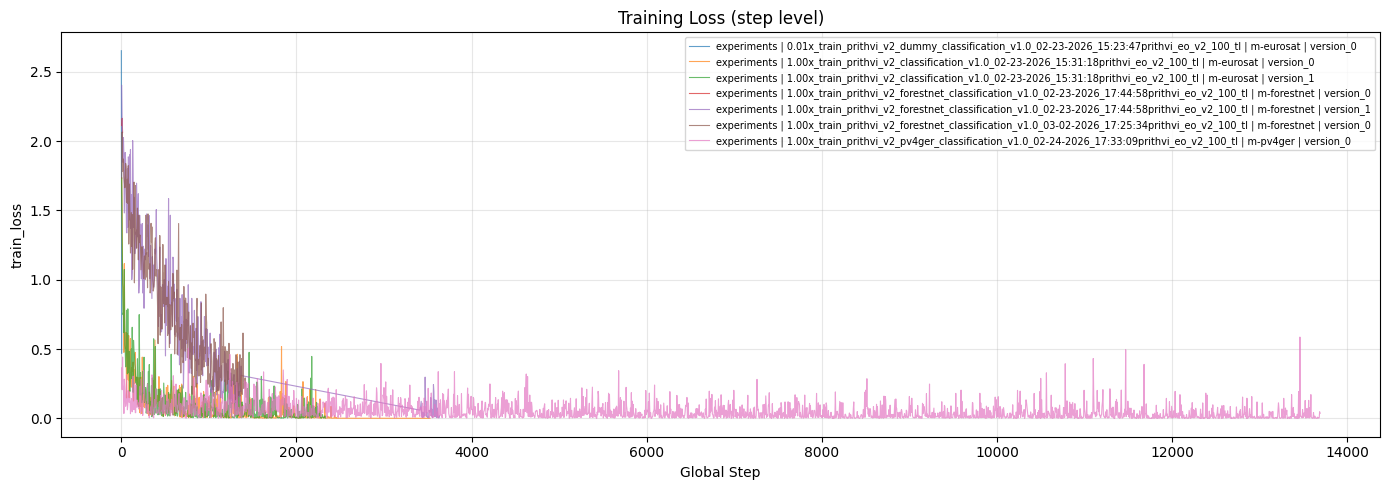

In [6]:
if "train_loss" in all_data.columns:
    train_steps = all_data.dropna(subset=["train_loss"]).copy()
    train_steps["train_loss"] = pd.to_numeric(train_steps["train_loss"], errors="coerce")

    fig, ax = plt.subplots(figsize=(14, 5))
    for lbl, grp in train_steps.groupby("run_label"):
        grp_sorted = grp.sort_values("step")
        ax.plot(grp_sorted["step"], grp_sorted["train_loss"], alpha=0.7, label=lbl, linewidth=0.8)

    ax.set_xlabel("Global Step")
    ax.set_ylabel("train_loss")
    ax.set_title("Training Loss (step level)")
    ax.legend(fontsize=7, loc="best")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No train_loss column found.")

## Final metrics — bar chart comparison

For each run we take the **best** val metric (e.g., best val_Accuracy across all epochs), then
show the corresponding test metric alongside it.

In [7]:
def best_epoch_summary(epoch_df: pd.DataFrame) -> pd.DataFrame:
    """Return one row per run with the epoch of *best* val metric and all associated scores."""
    # Choose the primary val metric for each run (Accuracy, F1Score, or Jaccard)
    val_metric_priority = ["val_Accuracy", "val_F1Score", "val_Jaccard"]

    rows = []
    for lbl, grp in epoch_df.groupby("run_label"):
        for vm in val_metric_priority:
            if vm in grp.columns and grp[vm].notna().any():
                best_idx = grp[vm].idxmax()
                best_row = grp.loc[best_idx].copy()
                best_row["primary_val_metric"] = vm
                rows.append(best_row)
                break

    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).reset_index(drop=True)


best_df = best_epoch_summary(epoch_df)
print("Best-epoch summary:")
display_cols = ["run_label", "epoch", "primary_val_metric"] + available_metric_cols
best_df[[c for c in display_cols if c in best_df.columns]]

Best-epoch summary:


,run_label,epoch,primary_val_metric,train_loss,train_Accuracy,val_Accuracy,val_loss/dataloader_idx_0,test_Accuracy,test_loss,test_loss/dataloader_idx_1
0,experiments | 0.01x_train_prithvi_v2_dummy_cla...,4,val_Accuracy,0.469780,1.000000,0.483000,1.975307,0.495000,NaN,1.941286
1,experiments | 1.00x_train_prithvi_v2_classific...,39,val_Accuracy,0.001692,1.000000,0.954000,0.187625,0.940000,NaN,0.229618
2,experiments | 1.00x_train_prithvi_v2_classific...,20,val_Accuracy,0.199211,0.989500,0.948000,0.221228,0.935000,NaN,0.271017
3,experiments | 1.00x_train_prithvi_v2_forestnet...,1,val_Accuracy,1.505558,0.596535,0.539939,1.429886,0.523666,NaN,1.496837
4,experiments | 1.00x_train_prithvi_v2_forestnet...,1,val_Accuracy,1.040415,0.606590,0.548028,1.391745,0.468278,NaN,1.579723
5,experiments | 1.00x_train_prithvi_v2_pv4ger_cl...,20,val_Accuracy,0.003360,0.985949,0.955956,0.161785,0.968969,NaN,0.119849


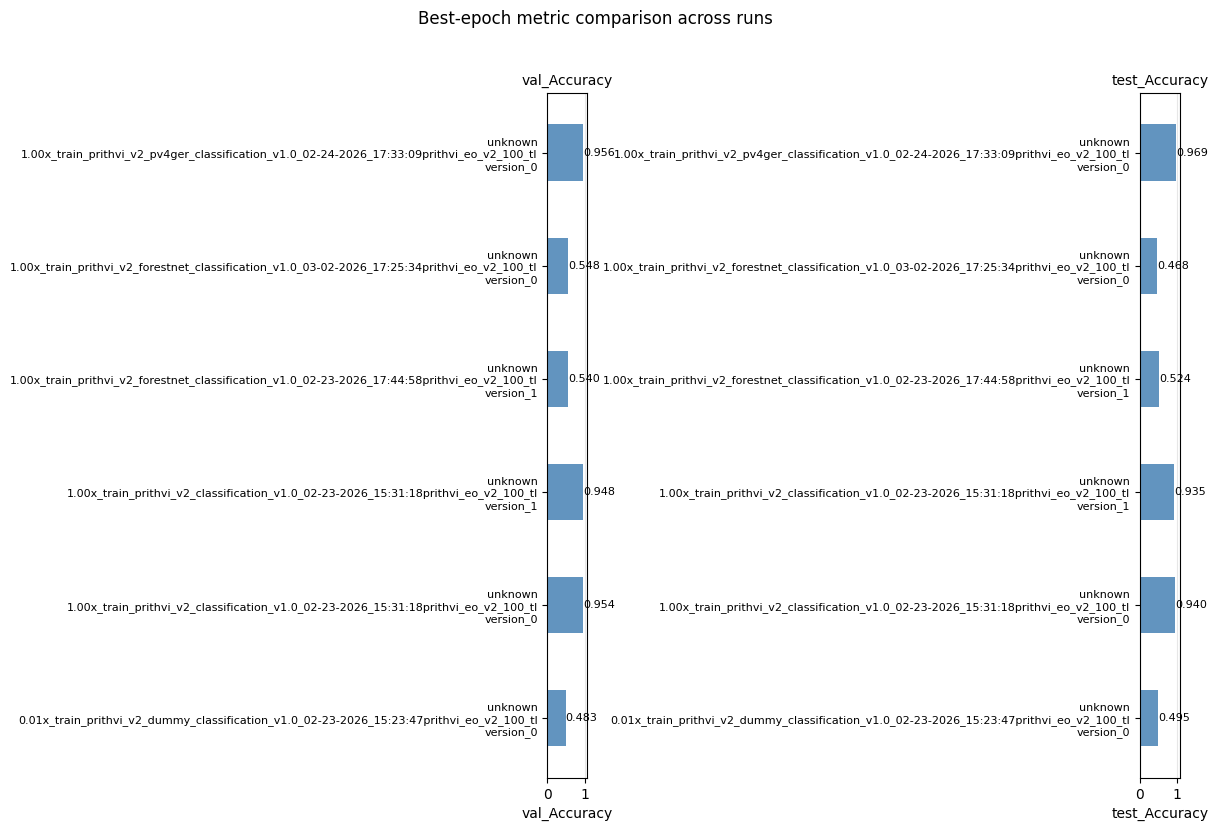

In [8]:
def bar_comparison(best_df: pd.DataFrame, metrics: list[str]):
    """Side-by-side bar chart for a list of metrics across all runs."""
    plot_metrics = [m for m in metrics if m in best_df.columns and best_df[m].notna().any()]
    if not plot_metrics:
        print("None of the requested metrics have data.")
        return

    # Build a short, human-readable label from structured columns
    def make_short_label(row):
        parts = [row["partition"], row["dataset"]]
        if row.get("model_variant", "unknown") not in ("unknown", None, ""):
            parts.append(row["model_variant"])
        parts.append(row["version"])
        return "\n".join(parts)

    df = best_df.copy()
    df["short_label"] = df.apply(make_short_label, axis=1)
    df = df.set_index("short_label")[plot_metrics].apply(pd.to_numeric, errors="coerce")

    n_metrics = len(plot_metrics)
    bar_height = 0.5
    n_runs = len(df)
    fig_h = max(4, n_runs * (bar_height + 0.6) + 1.5)

    fig, axes = plt.subplots(1, n_metrics, figsize=(6 * n_metrics, fig_h), squeeze=False)
    axes = axes[0]

    for ax, metric in zip(axes, plot_metrics):
        vals = df[metric].dropna()
        if vals.empty:
            ax.set_title(f"{metric}\n(no data)")
            continue
        y_pos = range(len(vals))
        bars = ax.barh(y_pos, vals.values, height=bar_height, color="steelblue", alpha=0.85)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(vals.index, fontsize=8)
        ax.set_xlabel(metric)
        ax.set_title(metric, fontsize=10)
        ax.set_xlim(0, max(1.0, vals.max() * 1.12))
        for bar, v in zip(bars, vals.values):
            ax.text(v + 0.005, bar.get_y() + bar.get_height() / 2,
                    f"{v:.3f}", va="center", fontsize=8)
        ax.grid(True, axis="x", alpha=0.3)

    plt.suptitle("Best-epoch metric comparison across runs", y=1.02)
    plt.tight_layout()
    plt.show()


bar_comparison(best_df, ["val_Accuracy", "val_F1Score", "val_Jaccard",
                         "test_Accuracy", "test_F1Score", "test_Jaccard"])


## Dataset-level breakdown

Group results by dataset so you can compare multiple model variants / seeds on the same task.

In [9]:
summary_metric_cols = [c for c in ["val_Accuracy", "val_F1Score", "val_Jaccard",
                                    "test_Accuracy", "test_F1Score", "test_Jaccard"]
                       if c in best_df.columns]

pivot_table = (
    best_df
    .set_index(["dataset", "model_variant", "seed", "version"])[summary_metric_cols]
    .apply(pd.to_numeric, errors="coerce")
)
pivot_table

val_Accuracy  \
dataset                                            model_variant seed        version                   
0.01x_train_prithvi_v2_dummy_classification_v1.... unknown       m-eurosat   version_0      0.483000   
1.00x_train_prithvi_v2_classification_v1.0_02-2... unknown       m-eurosat   version_0      0.954000   
                                                                             version_1      0.948000   
1.00x_train_prithvi_v2_forestnet_classification... unknown       m-forestnet version_1      0.539939   
1.00x_train_prithvi_v2_forestnet_classification... unknown       m-forestnet version_0      0.548028   
1.00x_train_prithvi_v2_pv4ger_classification_v1... unknown       m-pv4ger    version_0      0.955956   

                                                                                        test_Accuracy  
dataset                                            model_variant seed        version                   
0.01x_train_prithvi_v2_dummy_classification_v1.... unknown       m-eurosat   version_0       0.495000  
1.00x_train_prithvi_v2_classification_v1.0_02-2... unknown       m-eurosat   version_0       0.940000  
                                                                             version_1       0.935000  
1.00x_train_prithvi_v2_forestnet_classification... unknown       m-forestnet version_1       0.523666  
1.00x_train_prithvi_v2_forestnet_classification... unknown       m-forestnet version_0       0.468278  
1.00x_train_prithvi_v2_pv4ger_classification_v1... unknown       m-pv4ger    version_0       0.968969

## Val vs. Test scatter

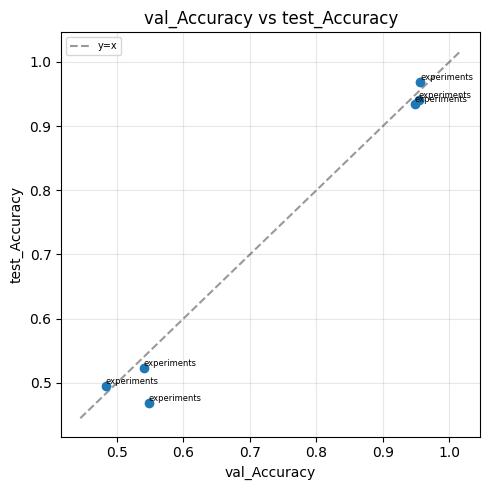

In [10]:
val_test_pairs = [
    ("val_Accuracy", "test_Accuracy"),
    ("val_F1Score", "test_F1Score"),
    ("val_Jaccard", "test_Jaccard"),
]

pairs_to_plot = [(v, t) for v, t in val_test_pairs
                 if v in best_df.columns and t in best_df.columns
                 and best_df[v].notna().any() and best_df[t].notna().any()]

if pairs_to_plot:
    fig, axes = plt.subplots(1, len(pairs_to_plot), figsize=(5 * len(pairs_to_plot), 5), squeeze=False)
    for ax, (v_col, t_col) in zip(axes[0], pairs_to_plot):
        sub = best_df[["run_label", v_col, t_col]].dropna()
        ax.scatter(sub[v_col], sub[t_col], zorder=3)
        for _, row in sub.iterrows():
            ax.annotate(
                row["run_label"].split(" | ")[0],  # show group only to save space
                (row[v_col], row[t_col]),
                fontsize=6, ha="left", va="bottom"
            )
        lo = min(sub[v_col].min(), sub[t_col].min()) * 0.95
        hi = max(sub[v_col].max(), sub[t_col].max()) * 1.05
        ax.plot([lo, hi], [lo, hi], "k--", alpha=0.4, label="y=x")
        ax.set_xlabel(v_col)
        ax.set_ylabel(t_col)
        ax.set_title(f"{v_col} vs {t_col}")
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No matching val/test metric pairs found.")

## Raw best-epoch table (full detail)

In [11]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:.4f}".format)
best_df[[c for c in best_df.columns if c != "csv_path"]].sort_values(["dataset", "seed", "version"])

,run_label,group,dataset,seed,version,model_variant,partition,epoch,train_loss,train_Accuracy,val_Accuracy,val_loss/dataloader_idx_0,test_Accuracy,test_loss,test_loss/dataloader_idx_1,primary_val_metric
0,experiments | 0.01x_train_prithvi_v2_dummy_classification_v1.0_02-23-2026_15:23:47prithvi_eo_v2_100_tl | m-eurosat | version_0,experiments,0.01x_train_prithvi_v2_dummy_classification_v1.0_02-23-2026_15:23:47prithvi_eo_v2_100_tl,m-eurosat,version_0,unknown,unknown,4,0.4698,1.0000,0.4830,1.9753,0.4950,NaN,1.9413,val_Accuracy
1,experiments | 1.00x_train_prithvi_v2_classification_v1.0_02-23-2026_15:31:18prithvi_eo_v2_100_tl | m-eurosat | version_0,experiments,1.00x_train_prithvi_v2_classification_v1.0_02-23-2026_15:31:18prithvi_eo_v2_100_tl,m-eurosat,version_0,unknown,unknown,39,0.0017,1.0000,0.9540,0.1876,0.9400,NaN,0.2296,val_Accuracy
2,experiments | 1.00x_train_prithvi_v2_classification_v1.0_02-23-2026_15:31:18prithvi_eo_v2_100_tl | m-eurosat | version_1,experiments,1.00x_train_prithvi_v2_classification_v1.0_02-23-2026_15:31:18prithvi_eo_v2_100_tl,m-eurosat,version_1,unknown,unknown,20,0.1992,0.9895,0.9480,0.2212,0.9350,NaN,0.2710,val_Accuracy
3,experiments | 1.00x_train_prithvi_v2_forestnet_classification_v1.0_02-23-2026_17:44:58prithvi_eo_v2_100_tl | m-forestnet | version_1,experiments,1.00x_train_prithvi_v2_forestnet_classification_v1.0_02-23-2026_17:44:58prithvi_eo_v2_100_tl,m-forestnet,version_1,unknown,unknown,1,1.5056,0.5965,0.5399,1.4299,0.5237,NaN,1.4968,val_Accuracy
4,experiments | 1.00x_train_prithvi_v2_forestnet_classification_v1.0_03-02-2026_17:25:34prithvi_eo_v2_100_tl | m-forestnet | version_0,experiments,1.00x_train_prithvi_v2_forestnet_classification_v1.0_03-02-2026_17:25:34prithvi_eo_v2_100_tl,m-forestnet,version_0,unknown,unknown,1,1.0404,0.6066,0.5480,1.3917,0.4683,NaN,1.5797,val_Accuracy
5,experiments | 1.00x_train_prithvi_v2_pv4ger_classification_v1.0_02-24-2026_17:33:09prithvi_eo_v2_100_tl | m-pv4ger | version_0,experiments,1.00x_train_prithvi_v2_pv4ger_classification_v1.0_02-24-2026_17:33:09prithvi_eo_v2_100_tl,m-pv4ger,version_0,unknown,unknown,20,0.0034,0.9859,0.9560,0.1618,0.9690,NaN,0.1198,val_Accuracy
